# Avaliação Estatística de Otimizadores em Redes Neurais Multicamadas: Um Estudo Experimental com Múltiplas Inicializações

#### A.7 Otimizadores

### 🧝📚⚔️ A trilha da acadêmica ⚔️📚🧝

**Aluna**: Bruna Guedes Pereira <br>
**Docente**: Daniel Roberto Cassar 

## Introdução

Este trabalho investiga o impacto da escolha do algoritmo de otimização no treinamento de redes neurais artificiais do tipo Perceptron Multicamadas (MLP) aplicados a um problema de classificação binária. Em tarefas de aprendizado supervisionado, a eficiência e a estabilidade do processo de treinamento dependem diretamente da forma como os parâmetros do modelo são atualizados ao longo das iterações, tornando os otimizadores um componente central no desempenho final [16].

O estudo utiliza o conjunto de dados **Wine Quality Dataset**, amplamente empregado na literatura para avaliação de modelos de aprendizado de máquina [1]. Esse conjunto contém 11 atributos numéricos relacionados propriedades físico-químicas de vinhos, como acidez, pH, teor alcoólico e concentração de compostos, associados a uma variável de qualidade originalmente contínua. Para adequar o problema ao contexto de classificação, a variável alvo foi transformada em binária a partir de um limiar de qualidade, resultando em duas classes. A distribuição das classes apresenta 4113 amostras na classe majoritária e 2384 na classe minoritária, correspondendo aproximadamente a 63% e 37%, respectivamente (conjunto moderadamente desbalanceado [17]). Esse nível de desbalanceamento torna o problema mais desafiador e permite analisar como diferentes algoritmos de otimização se comportam diante dessa característica dos dados.

## Metodologia 

Foi realizada a comparação de diferentes algoritmos de otimização baseados em gradiente — SGD, SGD com momento, AdaGrad, RMSProp e Adam. Para garantir uma análise mais justa, todos os modelos compartilham a mesma arquitetura de rede, os mesmos hiperparâmetros principais e os mesmos particionamentos de dados. Adicionalmente, foram consideradas múltiplas inicializações aleatórias, a fim de capturar a variabilidade inerente ao processo de treinamento e promover uma avaliação mais precisa dos método de otimização.

Os experimentos envolvem a análise de Curvas de Aprendizado (CAs), a avaliação de métricas de desempenho em conjuntos de validação e teste, e a aplicação de testes estatísticos T de Student pareados para comparação entre os otimizadores. Dessa forma, o trabalho busca não apenas identificar quais métodos apresentam melhor desempenho médio, mas também compreender sua estabilidade, comportamento de convergência e sensibilidade às condições iniciais.

## Implementação

Antes de utilizar o dataset, certifique-se executar o comando `pip install ucimlrepo`.

### Importações

A seguir, apresenta-se a justificativa de cada biblioteca utilizada:

* `ucimlrepo` (`fetch_ucirepo`): Utilizado para acessar e carregar diretamente conjuntos de dados do repositório UCI, permitindo a obtenção do dataset Breast Cancer Coimbra.

* `pandas (pd)`: Biblioteca fundamental para manipulação e análise de dados estruturados. É empregada para organizar o conjunto de dados em DataFrames, facilitando operações como limpeza e seleção de variáveis [5].

* `numpy (np)`: Fornece suporte para operações numéricas eficientes com _arrays_ multidimensionais. É amplamente utilizado em cálculos vetoriais e manipulação de dados em formato numérico [6].

* `torch`: Biblioteca principal do PyTorch, responsável por fornecer a infraestrutura para computação tensorial e execução de modelos de aprendizado profundo [3].

* `torch.nn (nn)`: Contém classes e funções para a construção de redes neurais, como camadas (_layers_), funções de ativação e definição de arquiteturas do tipo MLP [3].

* `torch.optim (optim)`: Fornece algoritmos de otimização utilizados no treinamento do modelo [3].

* `matplotlib.pyplot (plt)`: Utilizada para visualização de dados e resultados.

* `random`: Para garantir a reproutibilidade total, a documentação oficial do PyTorch recomenda definir a semente da biblioteca `random` padrão [3].

* `itertools`: fornece ferramentas para gerar combinações e permutações de forma eficiente (usado para comparar pares de otimizadores no teste t) [23].

* `torch.utils.data (DataLoader, TensorDataset)`: permite estruturar os dados e carregá-los em mini-batches com embaralhamento e reprodutibilidade durante o treinamento [22].

* `sklearn.model_selection (train_test_split, StratifiedKFold)`:

    * `train_test_split`: Divide os dados em conjuntos de treino e teste.
    * `StratifiedKFold`: Implementa validação cruzada estratificada, garantindo que a proporção das classes seja mantida em cada partição, o que é essencial em problemas de classificação.

* `sklearn.preprocessing` (_StandardScaler_): Responsável pela padronização dos dados, ajustando as variáveis para média zero e desvio padrão unitário [7].

* `sklearn.metrics`: Conjunto de métricas para avaliação do modelo [7]:

  * `accuracy_score`: Mede a proporção de acertos.
  * `f1_score`: Equilibra precisão e _recall_.
  * `roc_auc_score`: Avaliam o desempenho do modelo em diferentes limiares de decisão.

* `scipy.stats (ttest_rel)`: Utilizada para executar o teste t pareado de Student (_paired t-test_)

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import itertools

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import ttest_rel

### Configurações

Neste trecho, são definidas múltiplas sementes aleatórias para avaliar a robustez dos resultados e é criada uma estrutura para armazenar os resultados de cada execução.

In [3]:
SEEDS = [61455, 123, 999]

results_all_seeds = {}

### Importação do dataset

Em seguida, foi realizado o carregamento, organização e início do pré-processamento dos dados, preparando o conjunto para uso em um modelo de classificação. Não haviam valores ausentes no dataset, conforme especificado na referência [1].

In [4]:
dataset = fetch_ucirepo(id=186)

X = dataset.data.features # atributos
y = dataset.data.targets # target

# Combina atributos e alvo em um único DataFrame, juntando horizontalmente
df = pd.concat([X, y], axis=1)

# Converte o problema em classificação binária
df['target'] = (df['quality'] >= 6).astype(int)

# Remove a variável original contínua para evitar redundância
df = df.drop(columns=['quality'])

# Remove possíveis valores ausentes do conjunto
df = df.dropna()

# Separa novamente as features, agora como array NumPy
X = df.drop(columns=['target']).values

# Define o vetor de rótulos binários
y = df['target'].values

### Multilayer Perceptron (MLP)

O *Multilayer Perceptron* (MLP) é uma arquitetura de rede neural artificial do tipo *feedforward*, composta por múltiplas camadas de neurônios artificiais organizadas em uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída [9].

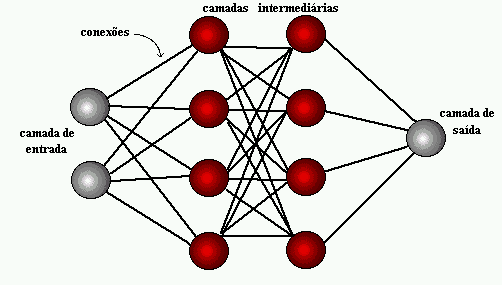

_Organização em camadas. Fonte: referência [11]_.

Cada neurônio realiza uma combinação linear das entradas: 

$$ z = Wx + b$$

onde: 

* $W$: pesos
* $x$: entrada
* $b$: viés.

Em seguida, ocorre a aplicação de uma função de ativação não linear, permitindo que a rede aprenda relações complexas entre as variáveis. Neste trabalho, a função utilizada foi a ReLU (_Rectified Linear Unit_):

$$ f(x) = max (0,x)$$

Essa função atua de forma simples: valores negativos são transformados em zero, enquanto valores positivos são mantidos inalterados. Com isso, a ReLU introduz não linearidade no modelo sem alterar a magnitude dos valores positivos. Do ponto de vista prático, isso implica que neurônios com saída negativa são “desativados”, contribuindo com valor nulo para a próxima camada, enquanto neurônios com saída positiva permanecem ativos. Esse comportamento favorece representações mais esparsas e pode contribuir para a redução de ruído.

Depois, o treinamento do MLP é realizado por meio do algoritmo de retropropagação do erro (*backpropagation*), em conjunto com métodos de otimização. Durante esse processo, os pesos da rede são ajustados iterativamente com o objetivo de minimizar uma função de perda.

Devido à sua flexibilidade e capacidade de generalização, o MLP é amplamente utilizado em tarefas de classificação e regressão, sendo particularmente adequado para dados tabulares, como no presente trabalho.

### Escolha de hiperparâmetros fixos

Cada _feature_ do dataset entra na rede através de um neurônio individual na camada de entrada. Nesse caso, como há 11 atributos físico-químicos, existem 11 neurônios de entrada.

A arquitetura adotada ([32, 16]) representa uma rede de baixa a média complexidade, no formato decrescente, suficiente para capturar relações não lineares em dados tabulares sem introduzir excesso de parâmetros que poderiam levar ao _overfitting_ [18]. A taxa de aprendizado foi fixada em $10^{−3}$, valor amplamente utilizado na literatura como padrão inicial, especialmente para métodos adaptativos [15].

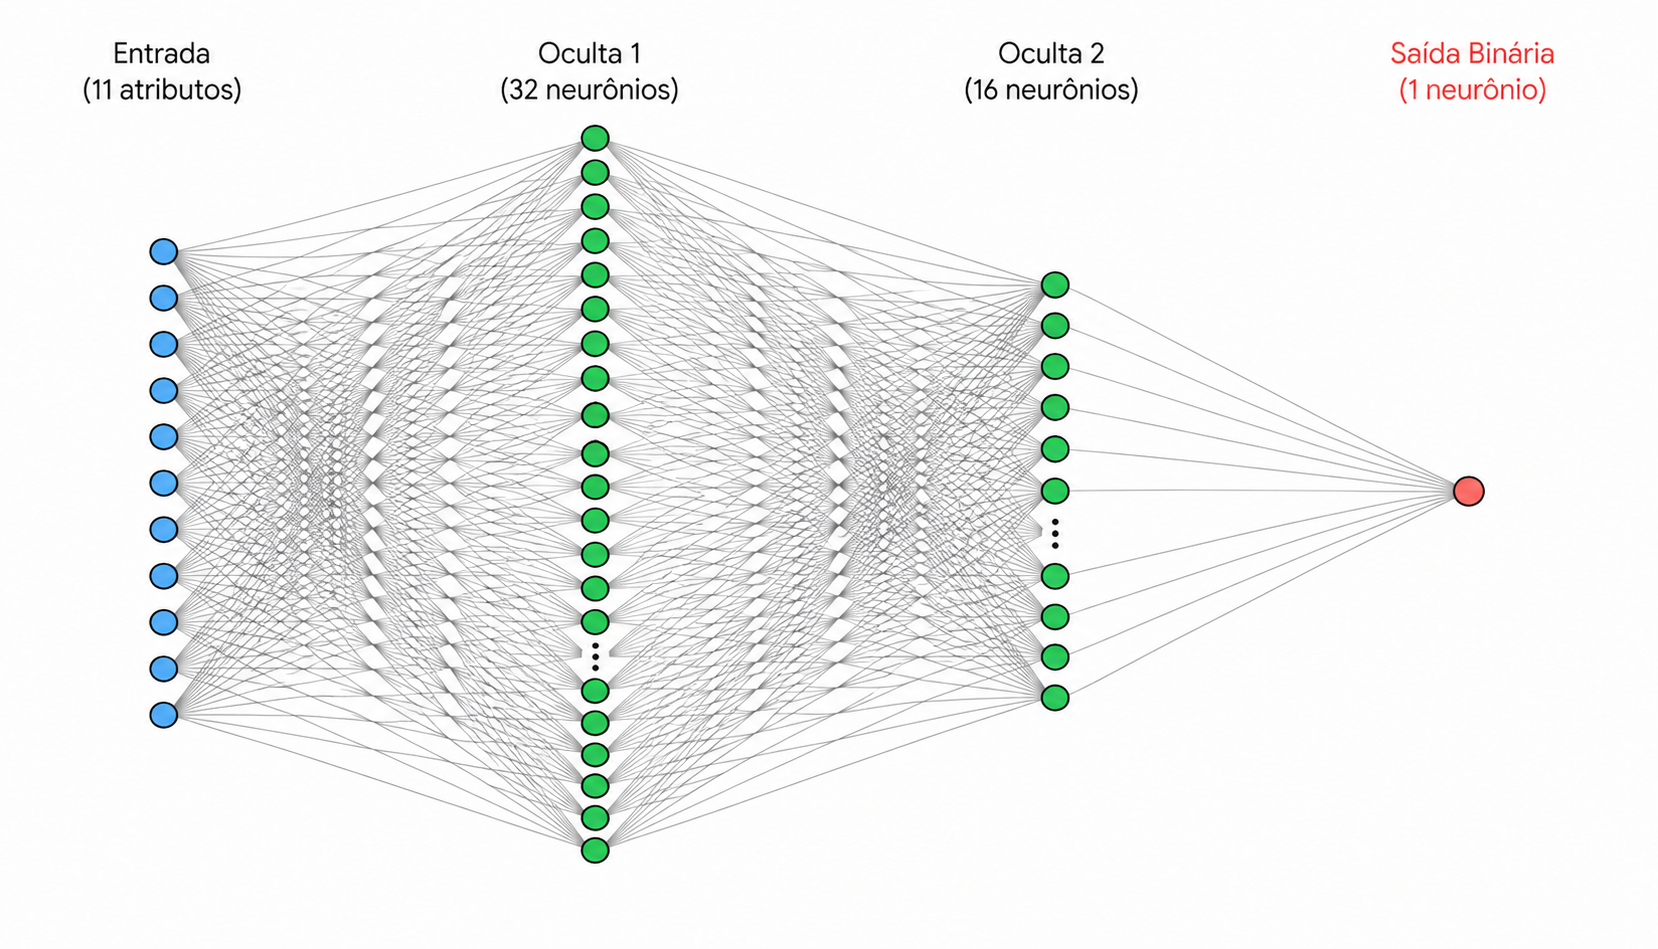

_(Imagem criada com Inteligência Artificial.)_

In [5]:
hidden_layers = [32, 16]
lr = 1e-3

## Execução experimental e variação estocástica

As etapas subsequentes serão realizas para cada semente aleatória definida.

Para cada valor de semente, são fixados os geradores de números aleatórios das bibliotecas `NumPy`, `PyTorch` e `Python` padrão, garantindo reprodutibilidade parcial dentro de cada execução. Além disso, são configuradas opções do backend do PyTorch para priorizar determinismo, reduzindo variações decorrentes da execução em hardware paralelo.

### Divisão dos dados

A divisão dos dados em conjuntos de treino, validação e teste constitui um princípio fundamental no treinamento de redes neurais, pois permite separar claramente três processos distintos: o aprendizado dos parâmetros do modelo, a seleção de hiperparâmetros e a avaliação final de generalização. Essa separação é essencial para evitar viés otimista e garantir que o desempenho reportado reflita, de fato, a capacidade do modelo de generalizar para dados não vistos.

No contexto deste trabalho, foi adotada uma estratégia de divisão hierárquica dos dados, resultando em três subconjuntos independentes: treino, validação externa e teste. Inicialmente, o conjunto completo foi particionado de modo que 80% dos dados foram destinados a um conjunto intermediário (`X_temp`, `y_temp`), enquanto os 20% restantes foram reservados para o conjunto de teste (`X_test`, `y_test`). Esse último permanece completamente isolado ao longo de todo o processo de desenvolvimento, sendo utilizado apenas ao final, como forma de obter uma estimativa imparcial do desempenho do modelo em dados novos.

Em seguida, o conjunto intermediário (80%) foi novamente subdividido: 80% desses dados foram utilizados para treino (`X_train`), correspondendo a aproximadamente 64% do total original, enquanto os 20% restantes foram destinados à validação externa (`X_val_ext`), representando cerca de 16% dos dados. Essa divisão é realizada separadamente para cada valor de semente aleatória, de forma que cada execução do experimento gera partições ligeiramente diferentes, permitindo avaliar a robustez dos resultados frente à variação estocástica do processo de amostragem.

O conjunto de treino (`X_train`) é utilizado no processo de ajuste dos parâmetros da rede neural, isto é, os pesos e vieses são aprendidos por meio do algoritmo de _backpropagation_. Além disso, ele serve como base para a comparação entre diferentes configurações de treinamento, já que todas as variantes de otimizadores são avaliadas sob o mesmo cenário de treinamento dentro de cada semente.

Por outro lado, o conjunto de validação externa (`X_val_ext`) é utilizado durante o desenvolvimento para monitoramento do desempenho do modelo e cálculo de métricas intermediárias, permitindo observar a estabilidade do aprendizado e a capacidade de generalização antes da avaliação final. Já o conjunto de teste (`X_test`) é utilizado apenas uma única vez ao término de cada execução, sendo responsável por fornecer uma estimativa final e imparcial do desempenho do modelo.

De forma geral, a divisão em treino, validação e teste é indispensável no treinamento de redes neurais, pois impede que decisões de modelagem sejam influenciadas por dados que deveriam servir exclusivamente para avaliação. Isso assegura que o modelo não apenas se ajuste bem aos dados observados, mas também apresente capacidade de generalização.

### Normalização

Foi utilizado o método de padronização `StandardScaler`, que transforma cada atributo de modo que tenha média igual a 0 e desvio padrão igual a 1, ajustando a distribuição dos dados para se aproximar de uma distribuição normal padrão.

Essa etapa é fundamental para redes neurais porque evita que atributos com escalas maiores dominem o treinamento, melhora a estabilidade numérica e acelera a convergência do algoritmo de otimização. Sem normalização, o processo de aprendizado pode se tornar instável ou muito lento. [4]

### Criando e treinando uma rede neural com `Pytorch`

Inicialmente, foi definida a classe `MLP`, que herda de `nn.Module`, a classe base para construção de modelos no PyTorch. No método construtor (`__init__`), a arquitetura da rede é construída dinamicamente a partir dos parâmetros fornecidos: dimensão de entrada (`input_dim`), lista de camadas ocultas (`hidden_layers`).

A rede é montada como uma sequência de camadas totalmente conectadas (_fully connected_), onde, para cada camada oculta:

* é adicionada uma transformação linear (`nn.Linear`), responsável por combinar as entradas com pesos e viés;
* aplica-se a função de ativação ReLU, introduzindo não linearidade no modelo;

Ao final da arquitetura, é adicionada uma camada de saída com apenas um neurônio (`nn.Linear(prev, 1)`), adequada para problemas de classificação binária. Todas as camadas são organizadas por meio de `nn.Sequential`, o que simplifica a definição do fluxo direto da rede.

O método `forward` define como os dados percorrem a rede: a entrada `x` é passada sequencialmente pelas camadas definidas, produzindo a saída do modelo.

Na sequência, foi implementada a função `train_model`, responsável pelo treinamento da rede.

#### Backpropagation e otimização

O algoritmo de _backpropagation_ [11] calcula como a função de perda varia em relação a cada parâmetro da rede neural, permitindo sua otimização via descida do gradiente. O processo ocorre em duas etapas principais: 
* inicialmente, realiza-se a propagação direta (_forward pass_), na qual os dados de entrada percorrem a rede camada por camada, sendo transformados por combinações lineares ($z=w⋅x+b$) e funções de ativação, produzindo uma saída final e, consequentemente, um valor de perda.
* Em seguida, na etapa de retropropagação, aplica-se a regra da cadeia para calcular os gradientes da perda em relação aos pesos e vieses propagando o erro da saída em direção às camadas iniciais. Nesse contexto, a função de ativação ReLU exerce papel crucial, pois sua derivada é igual a 1 para valores positivos e 0 para valores negativos. Isso implica que, durante o cálculo dos gradientes, neurônios cuja entrada $z$ seja positiva permitem a propagação do erro e, portanto, contribuem para a atualização dos parâmetros; por outro lado, neurônios com 
$z<0$ têm derivada nula, bloqueando o fluxo do gradiente e impedindo ajustes nos pesos associados naquela iteração. Assim, a ReLU atua como um filtro no processo de aprendizado, determinando quais neurônios participam efetivamente da atualização dos parâmetros em cada passo do treinamento.

#### Taxa de aprendizado e algoritmos de otimização

A taxa de aprendizado (_learning rate_) controla o tamanho das atualizações realizadas nos parâmetros da rede neural durante o treinamento. Em métodos tradicionais, como o SGD clássico, essa taxa permanece fixa para todos os parâmetros ao longo de todo o processo de treinamento. Em métodos com taxa de aprendizado adaptativa, o valor efetivo da atualização é ajustado dinamicamente durante o treinamento. Em vez de utilizar o mesmo passo para todos os parâmetros, cada peso pode receber uma taxa de aprendizado diferente, calculada a partir do histórico dos gradientes.

De forma geral, parâmetros associados a gradientes grandes ou frequentes tendem a receber atualizações menores, enquanto parâmetros com gradientes pequenos ou raros podem receber atualizações relativamente maiores. Esse mecanismo busca tornar o treinamento mais estável e eficiente, especialmente em problemas complexos e de alta dimensionalidade. Otimizadores como AdaGrad, RMSProp e Adam utilizam diferentes estratégias para implementar essa adaptação automática da taxa de aprendizado.

De maneira mais ampla, diferentes algoritmos de otimização definem distintas estratégias para utilizar os gradientes calculados durante o backpropagation na atualização dos parâmetros da rede neural. No código abaixo, é realizada a escolha do algoritmo de otimização utilizado durante o treinamento:

* __SGD (Stochastic Gradient Descent)__: é uma das formas mais simples e clássicas de otimização em redes neurais. A cada iteração, os parâmetros do modelo são atualizados na direção oposta ao gradiente da função de perda calculado sobre um mini-lote de dados. Apesar de simples e eficiente computacionalmente, o SGD pode apresentar convergência lenta e oscilações em regiões de alta curvatura da superfície de erro [12].

* __SGD com Momentum__: é uma extensão do SGD tradicional que adiciona um termo de inércia às atualizações dos parâmetros. Em vez de depender apenas do gradiente atual, o algoritmo acumula parcialmente os gradientes anteriores, suavizando oscilações e acelerando o movimento em direções consistentes. Esse mecanismo costuma melhorar a estabilidade e a velocidade de convergência do treinamento [12].

 * __Adagrad (Adaptive Gradient Algorithm)__: adapta individualmente a taxa de aprendizado de cada parâmetro com base na soma acumulada dos quadrados dos gradientes históricos. Parâmetros que recebem gradientes frequentes têm sua taxa de aprendizado reduzida ao longo do tempo, enquanto parâmetros menos atualizados mantêm passos relativamente maiores. Esse comportamento pode ser vantajoso em problemas com atributos esparsos, embora o método possa sofrer com redução excessiva da taxa de aprendizado ao longo do treinamento [10].

 * __RMSprop (Root Mean Square Propagation)__: foi proposto como uma correção ao problema de decaimento agressivo da taxa de aprendizado observado no Adagrad. Em vez de acumular todos os gradientes históricos, utiliza uma média exponencial dos quadrados dos gradientes, permitindo uma adaptação mais estável da taxa de aprendizado ao longo do tempo. Isso evita que o aprendizado se torne excessivamente lento em estágios avançados do treinamento [24].

 * __Adam (Adaptive Moment Estimation)__: combina os conceitos de momentum e adaptação individual da taxa de aprendizado. O método mantém médias móveis tanto dos gradientes quanto dos quadrados dos gradientes, permitindo atualizações adaptativas mais eficientes para cada parâmetro. Devido à sua estabilidade e rápida convergência, tornou-se um dos otimizadores mais utilizados em aprendizado profundo [12].

Em todos os casos, o processo segue o mesmo princípio geral: após o cálculo dos gradientes via _backpropagation_, os parâmetros são atualizados iterativamente com o objetivo de minimizar a função de perda. A principal diferença entre os métodos está na maneira como cada algoritmo define a direção e a magnitude das atualizações dos parâmetros.

#### Vantagens e desvantagens dos otimizadores

Cada otimizador apresenta características distintas em termos de estabilidade, velocidade de convergência e custo computacional.

* __SGD__: possui implementação simples e baixo custo computacional, além de frequentemente apresentar boa capacidade de generalização. Entretanto, pode convergir lentamente e apresentar oscilações significativas durante o treinamento, especialmente em superfícies de perda complexas.

* __SGD com Momentum__: reduz oscilações e acelera a convergência ao acumular gradientes passados. Apesar disso, ainda depende fortemente da escolha adequada da taxa de aprendizado e do parâmetro de momentum.

* __AdaGrad__: adapta automaticamente a taxa de aprendizado de cada parâmetro, sendo particularmente útil em problemas com atributos esparsos. Sua principal desvantagem é o decaimento acumulativo da taxa de aprendizado, que pode tornar o treinamento excessivamente lento após muitas iterações.

* __RMSProp__: corrige parcialmente o problema do AdaGrad utilizando médias móveis exponenciais dos gradientes quadráticos, mantendo taxas de aprendizado mais estáveis ao longo do treinamento. Contudo, ainda pode apresentar sensibilidade à escolha dos hiperparâmetros.

* __Adam__: combina momentum e adaptação individual da taxa de aprendizado, normalmente apresentando rápida convergência e bom desempenho prático em diversos problemas. Entretanto, alguns estudos apontam que o Adam pode apresentar pior capacidade de generalização em comparação ao SGD em determinadas aplicações.

### Função de perda

Foi utilizada a função `BCEWithLogitsLoss`, apropriada para problemas de classificação binária. Essa função opera diretamente sobre os _logits_ (saídas brutas da rede, antes de qualquer transformação) e combina, de forma integrada, duas etapas fundamentais [13, 14]:

* A função sigmoide. Essa transformação converte os _logits_ em valores no intervalo 
[0,1], que podem ser interpretados como probabilidades associadas à classe positiva:

$$ \sigma(x) = \frac {1}{1 + e^{-x}}.$$

* Cálculo da entropia cruzada binária, que mede o erro entre as probabilidades previstas e os rótulos reais. Intuitivamente, essa medida penaliza previsões incorretas, atribuindo penalizações maiores quando o modelo está confiante e errado, e menores quando a incerteza é maior.

Essa combinação é numericamente estável e recomendada para classificação binária.

Além disso, foi introduzido o parâmetro `pos_weight`, que ajusta o peso da classe positiva na função de perda. Isso é importante em cenários com desbalanceamento de classes. Ao aumentar o peso da classe minoritária (no caso, a classe positiva), o modelo passa a penalizar mais fortemente erros nessa classe, reduzindo o viés em favor da classe majoritária e contribuindo para um desempenho mais equilibrado.

O processo de treinamento foi estabelecido em 100 épocas. Em cada época:

* o modelo é colocado em modo de treinamento (`model.train()`),
* realiza-se a predição (`pred = model(X_tr)`);
* calcula-se a perda;
* os gradientes são zerados (`optimizer.zero_grad()`), recalculados via _backpropagation_ (`loss.backward()`) e utilizados para atualizar os pesos (`optimizer.step()`).

Ao final de cada época, o modelo é avaliado no conjunto de validação externa, utilizando `model.eval()` e desabilitando o cálculo de gradientes`torch.no_grad()`), permitindo avaliar o desempenho do modelo em dados não utilizados diretamente no ajuste dos parâmetros.

A perda de validação é registrada ao longo do treinamento e utilizada como métrica de acompanhamento do processo de otimização.

### Conversão para tensores

A conversão para tensores é necessária porque o PyTorch não opera diretamente sobre arrays do NumPy. Ele possui sua própria estrutura de dados — o tensor — que é fundamental para o funcionamento interno da biblioteca.

O NumPy foi projetado para computação numérica geral. Já o PyTorch foi projetado especificamente para aprendizado de máquina com diferenciação automática.

Dessa forma, apenas os tensores do PyTorch:

* suportam cálculo automático de gradientes (_autograd_)
* podem ser movidos facilmente para GPU
* são integrados ao sistema de otimização (_backpropagation_)

### _Batch Size_

O tamanho do lote (_batch size_) corresponde ao número de amostras utilizadas para calcular cada atualização dos parâmetros durante o treinamento da rede neural. Dependendo desse valor, o treinamento pode ocorrer em três configurações principais [19]:

* __Batch Gradient Descent__: utiliza todo o conjunto de treinamento para calcular o gradiente antes de cada atualização dos parâmetros. Nesse caso, ocorre apenas uma atualização por época. O método produz atualizações estáveis e determinísticas, porém apresenta maior custo computacional e menor frequência de atualização dos pesos.
  
* __Stochastic Gradient Descent (SGD)__: utiliza apenas uma amostra por atualização. Como consequência, os gradientes possuem alta variabilidade, tornando o treinamento mais ruidoso, porém frequentemente mais rápido em termos de aprendizado inicial *.

* __Mini-Batch Gradient Descent__: utiliza pequenos subconjuntos do conjunto de treinamento. Essa abordagem representa um equilíbrio entre estabilidade computacional e eficiência prática, sendo atualmente a forma mais utilizada no treinamento de redes neurais profundas.

Quando o batch contém todo o conjunto de treino, o gradiente calculado representa exatamente a média sobre todos os exemplos disponíveis. Isso reduz a variância das atualizações e produz trajetórias de treinamento mais estáveis. Entretanto, o custo computacional de cada atualização pode se tornar elevado em conjuntos de dados grandes.

Por outro lado, batches menores introduzem ruído estocástico nas estimativas do gradiente. Embora isso aumente a variabilidade das atualizações, frequentemente permite convergência empírica mais rápida para soluções com bom desempenho prático. Além disso, o ruído introduzido pode ajudar o treinamento a escapar de mínimos locais rasos e regiões planas da função de perda.

Neste trabalho, optou-se pelo uso de mini-batches para analisar o comportamento dos diferentes otimizadores. Essa configuração é particularmente importante porque algoritmos como SGD com Momentum, RMSProp e Adam foram desenvolvidos justamente para lidar com gradientes estocásticos e atualizações frequentes dos parâmetros.

<span style="font-size:12px;">
*É importante observar que o termo SGD (Stochastic Gradient Descent) pode ser utilizado em dois contextos relacionados. Originalmente, o termo descreve uma estratégia de treinamento em que os parâmetros são atualizados utilizando apenas uma amostra por vez. Entretanto, em bibliotecas modernas de aprendizado profundo, como PyTorch, SGD também passou a designar um otimizador específico baseado em atualizações diretas do gradiente, normalmente aplicado em conjunto com mini-batches. Assim, mesmo utilizando batches maiores que um, ainda é comum referir-se ao algoritmo simplesmente como SGD.
</span>

In [6]:
all_rows = []

for SEMENTE_ALEATORIA in SEEDS:

    torch.manual_seed(SEMENTE_ALEATORIA)
    np.random.seed(SEMENTE_ALEATORIA)
    random.seed(SEMENTE_ALEATORIA)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEMENTE_ALEATORIA
    )

    X_train, X_val_ext, y_train, y_val_ext = train_test_split(
        X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=SEMENTE_ALEATORIA
    )

    class MLP(nn.Module):
        def __init__(self, input_dim, hidden_layers):
            super().__init__()
            layers = []
            prev = input_dim

            for h in hidden_layers:
                layers.append(nn.Linear(prev, h))
                layers.append(nn.ReLU())
                prev = h

            layers.append(nn.Linear(prev, 1))
            self.model = nn.Sequential(*layers)

        def forward(self, x):
            return self.model(x)

    def train_model(model, X_tr, y_tr, X_val, y_val, lr,
                    optimizer_name="Adam", epochs=100, batch_size=64):

        dataset = TensorDataset(X_tr, y_tr)
        g = torch.Generator()
        g.manual_seed(SEMENTE_ALEATORIA)

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=g)

        if optimizer_name == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr)
        elif optimizer_name == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=lr)
        elif optimizer_name == "Momentum":
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        elif optimizer_name == "Adagrad":
            optimizer = optim.Adagrad(model.parameters(), lr=lr)
        elif optimizer_name == "RMSprop":
            optimizer = optim.RMSprop(model.parameters(), lr=lr)

        pos_weight = (len(y_tr) - y_tr.sum().item()) / y_tr.sum().item()
        pos_weight = torch.tensor([pos_weight], dtype=torch.float32)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        train_losses, val_losses = [], []

        for _ in range(epochs):
            model.train()
            epoch_loss = 0

            for X_batch, y_batch in loader:
                pred = model(X_batch)
                loss = criterion(pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            train_losses.append(epoch_loss / len(loader))

            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val).item()

            val_losses.append(val_loss)

        return train_losses, val_losses

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val_ext)
    X_test_scaled = scaler.transform(X_test)

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_ext, dtype=torch.float32).view(-1, 1)

    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    batch_sizes = [32, 128]
    optimizers = ["SGD", "Momentum", "Adagrad", "RMSprop", "Adam"]

    results = {}

    for batch in batch_sizes:
        results[batch] = {}

        for opt in optimizers:

            torch.manual_seed(SEMENTE_ALEATORIA)

            model = MLP(X_train.shape[1], hidden_layers)

            train_losses, val_losses = train_model(
                model,
                X_train_t, y_train_t,
                X_val_t, y_val_t,
                lr=lr,
                optimizer_name=opt,
                epochs=100,
                batch_size=batch
            )

            model.eval()
            with torch.no_grad():
                logits_test = model(X_test_t)
                probs_test = torch.sigmoid(logits_test).numpy().ravel()
                preds_test = (probs_test >= 0.5).astype(int)

                logits_val = model(X_val_t)
                probs_val = torch.sigmoid(logits_val).numpy().ravel()
                preds_val = (probs_val >= 0.5).astype(int)

            acc = accuracy_score(y_test, preds_test)
            f1 = f1_score(y_test, preds_test)
            auc = roc_auc_score(y_test, probs_test)

            val_acc = accuracy_score(y_val_ext, preds_val)
            val_f1 = f1_score(y_val_ext, preds_val)
            val_auc = roc_auc_score(y_val_ext, probs_val)

            results[batch][opt] = {
                "train_loss": train_losses,
                "val_loss": val_losses,
                "accuracy": acc,
                "f1": f1,
                "auc": auc,
                "val_f1": val_f1,
                "val_auc": val_auc
            }

            all_rows.append({
                "Seed": SEMENTE_ALEATORIA,
                "Batch": batch,
                "Optimizer": opt,
                "Test_F1": f1,
                "Val_F1": val_f1
            })

    results_all_seeds[SEMENTE_ALEATORIA] = results

### Teste T

Para complementar a comparação entre os otimizadores, foi utilizado o teste t de Student pareado (`paired t-test`). Esse teste estatístico tem como objetivo verificar se a diferença média entre dois métodos pode ser considerada estatisticamente significativa [25].

O teste t pareado foi escolhido para este trabalho porque os resultados comparados não são independentes. Cada otimizador foi avaliado sob exatamente as mesmas condições experimentais (mesmas sementes aleatórias, mesmos conjuntos de treino, validação e teste e mesma arquitetura de rede). Dessa forma, cada execução de um método possui uma execução correspondente diretamente comparável em outro método. O teste pareado é apropriado nesse contexto porque reduz parte da variabilidade experimental associada às diferenças entre execuções independentes.

O teste calcula uma estatística t baseada na diferença entre os resultados dos dois métodos comparados:

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

onde:

- $\bar{d}$ representa a média das diferenças entre os pares;
- $s_{d}$ representa o desvio padrão dessas diferenças;
- $n$ representa o número de pares analisados.

O valor-p (`p-value`) indica a probabilidade de observar diferenças iguais ou maiores que as encontradas assumindo que os dois métodos possuem desempenho equivalente. Em geral:

- $p < 0.05$: evidência estatística de diferença entre os métodos;
- $p \ge 0.05$: não há evidências suficientes para afirmar diferença estatística.

Neste trabalho, o teste foi aplicado sobre os valores de `F1-score` obtidos para cada otimizador em diferentes sementes aleatórias.


### Limitações da análise estatística

Apesar de útil como ferramenta exploratória, o teste realizado possui limitações importantes.

* O principal ponto é o número reduzido de execuções. Foram utilizadas apenas três sementes aleatórias, resultando em uma amostra muito pequena $n = 3$. Em amostras pequenas, o teste t apresenta baixo poder estatístico, tornando os valores-p menos estáveis e mais sensíveis a pequenas variações nos resultados.
* Além disso, o teste t assume que as diferenças entre os pares seguem aproximadamente uma distribuição normal. Com apenas três observações, essa hipótese não pode ser adequadamente verificada.
* Outro aspecto importante é que foram realizadas múltiplas comparações entre diferentes pares de otimizadores. Isso aumenta a probabilidade de ocorrência de falsos positivos (erro tipo I), especialmente sem correções estatísticas adicionais.

Dessa forma, os resultados do teste t devem ser interpretados como uma análise complementar e exploratória, e não como uma conclusão estatística definitiva sobre superioridade entre os métodos.

In [7]:
# DATAFRAME PARA TESTE
df_results = pd.DataFrame(all_rows)

# TESTE T PAREADO
print("\nTESTES T PAREADOS:\n")

for batch in [32, 128]:
    print(f"\nBatch = {batch}\n")
    
    for opt1, opt2 in itertools.combinations(optimizers, 2):
        
        d1 = df_results[(df_results["Optimizer"] == opt1) & (df_results["Batch"] == batch)]["Test_F1"].values
        d2 = df_results[(df_results["Optimizer"] == opt2) & (df_results["Batch"] == batch)]["Test_F1"].values

        t_stat, p_val = ttest_rel(d1, d2)

        print(f"{opt1} vs {opt2} -> t={t_stat:.4f}, p={p_val:.4f}")


TESTES T PAREADOS:


Batch = 32

SGD vs Momentum -> t=-2.2279, p=0.1557
SGD vs Adagrad -> t=-1.3136, p=0.3194
SGD vs RMSprop -> t=-3.0684, p=0.0918
SGD vs Adam -> t=-2.9518, p=0.0982
Momentum vs Adagrad -> t=8.3218, p=0.0141
Momentum vs RMSprop -> t=-3.5253, p=0.0719
Momentum vs Adam -> t=-0.2856, p=0.8020
Adagrad vs RMSprop -> t=-14.3965, p=0.0048
Adagrad vs Adam -> t=-6.3414, p=0.0240
RMSprop vs Adam -> t=3.9694, p=0.0580

Batch = 128

SGD vs Momentum -> t=-0.7966, p=0.5092
SGD vs Adagrad -> t=-0.7711, p=0.5213
SGD vs RMSprop -> t=-1.2846, p=0.3276
SGD vs Adam -> t=-1.2275, p=0.3445
Momentum vs Adagrad -> t=1.2937, p=0.3250
Momentum vs RMSprop -> t=-35.2848, p=0.0008
Momentum vs Adam -> t=-5.8293, p=0.0282
Adagrad vs RMSprop -> t=-17.3531, p=0.0033
Adagrad vs Adam -> t=-7.6225, p=0.0168
RMSprop vs Adam -> t=2.1919, p=0.1597


No teste t pareado, dois valores principais são analisados: a estatística t e o valor-p (_p-value_). A estatística t mede a magnitude da diferença entre os métodos em relação à variabilidade observada entre as execuções. Valores absolutos elevados de t indicam que a diferença média entre os métodos é grande quando comparada à dispersão dos resultados. Além disso, valores positivos indicam vantagem do primeiro método da comparação, enquanto valores negativos indicam vantagem do segundo método.

Já o valor-p representa a probabilidade de observar uma diferença igual ou maior que a encontrada assumindo que os dois métodos possuem desempenho equivalente. Valores pequenos de p sugerem que a diferença observada dificilmente ocorreu apenas por acaso. Convencionalmente, utiliza-se $p < 0.05$ como indicativo de evidência estatística de diferença entre os métodos.

Por exemplo, na comparação entre AdaGrad e RMSProp com batch size 32, obteve-se $t = -14.3965$ e $p = 0.0048$. O sinal negativo indica que o RMSProp apresentou desempenho superior ao AdaGrad, enquanto o baixo valor-p sugere evidência estatística de diferença entre os métodos. Em contraste, na comparação entre Momentum e Adam com batch size 32, obteve-se $t = -0.2856$ e $p = 0.8020$, indicando diferenças pequenas e sem evidência estatística relevante.

### Curva de Aprendizado (CAs)

As curvas de aprendizado são representações gráficas que descrevem a evolução do desempenho de um modelo ao longo do processo de treinamento [21]. Em problemas de aprendizado supervisionado, essas curvas normalmente são construídas a partir da função de perda (_loss_) ou de métricas de desempenho, avaliadas tanto no conjunto de treino quanto em um conjunto de validação, em função do número de épocas.

No contexto deste trabalho, as curvas de aprendizado são obtidas a partir das listas `train_losses` e `val_losses`, que armazenam, respectivamente, o valor da função de perda ao final de cada época para os dados de treino e para os dados de validação. Assim, cada ponto da curva representa o desempenho do modelo após uma iteração completa de atualização dos parâmetros.

A análise conjunta dessas duas curvas permite compreender a dinâmica do processo de aprendizado e avaliar a capacidade de generalização do modelo. Em particular, três comportamentos típicos podem ser identificados:

* **Subajuste (_underfitting_)**: ocorre quando tanto a _loss_ de treino quanto a de validação permanecem elevadas ao longo das épocas. Isso indica que o modelo não possui capacidade suficiente para capturar os padrões presentes nos dados, podendo estar associado a uma arquitetura muito simples, ou escolha inadequada de hiperparâmetros.

Abaixo, um exemplo de curva de aprendizado de treinamento mostrando um modelo com subajuste. Fonte: referência [21].

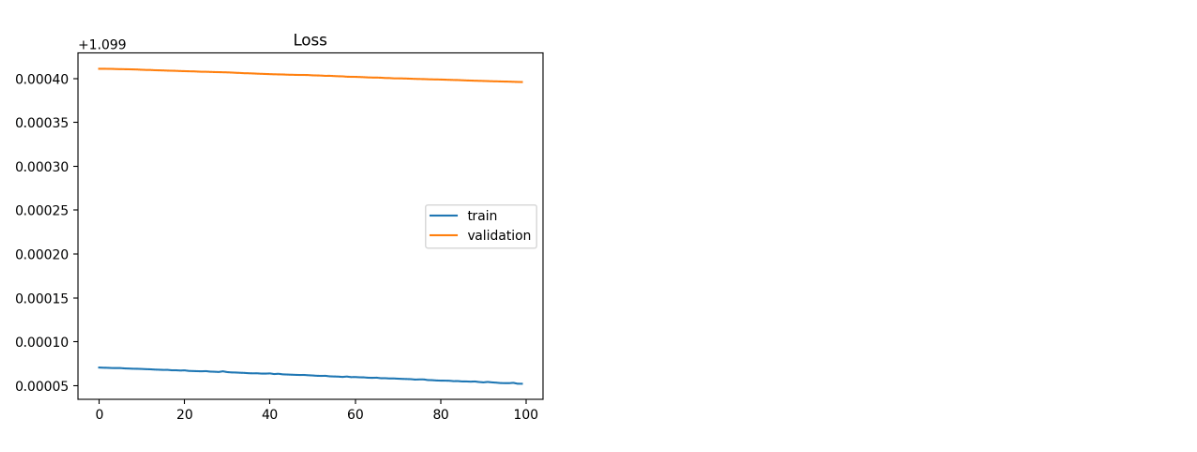

Um modelo com ajuste insuficiente também pode ser identificado por uma perda de treinamento decrescente que continua a diminuir até o final do gráfico. Isso demonstra que o modelo é capaz de mais aprendizado e desenvolvimento, e que o processo de treinamento foi encerrado prematuramente.

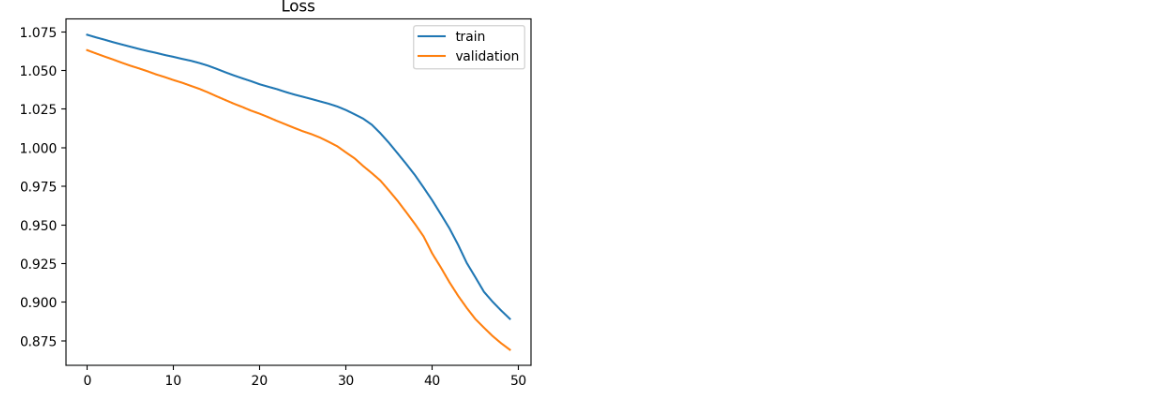

_Exemplo de curva de aprendizado de treinamento mostrando um modelo subajustado que requer treinamento adicional. Fonte: referência [21]_

* **Sobreajuste (_overfitting_)**: caracteriza-se por uma redução contínua da _loss_ de treino, acompanhada de estabilização ou aumento da loss de validação. Nesse cenário, o modelo passa a memorizar os dados de treino, perdendo capacidade de generalização para dados não vistos. O ponto de inflexão na perda de validação pode ser o ponto em que o treinamento pode ser interrompido.

O gráfico abaixo é um exemplo de sobreajuste. Fonte: referência [21].

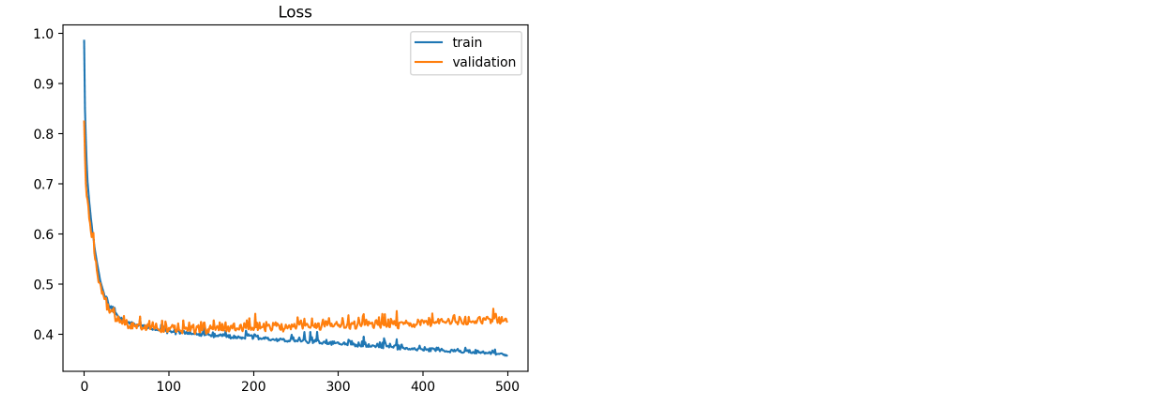

* **Boa generalização**: ocorre quando ambas as curvas apresentam valores baixos e comportamento semelhante ao longo das épocas, indicando que o modelo consegue aprender padrões relevantes sem se ajustar excessivamente aos dados de treino.

O gráfico abaixo mostra um exemplo de uma boa correspondência. Fonte: referência [21].

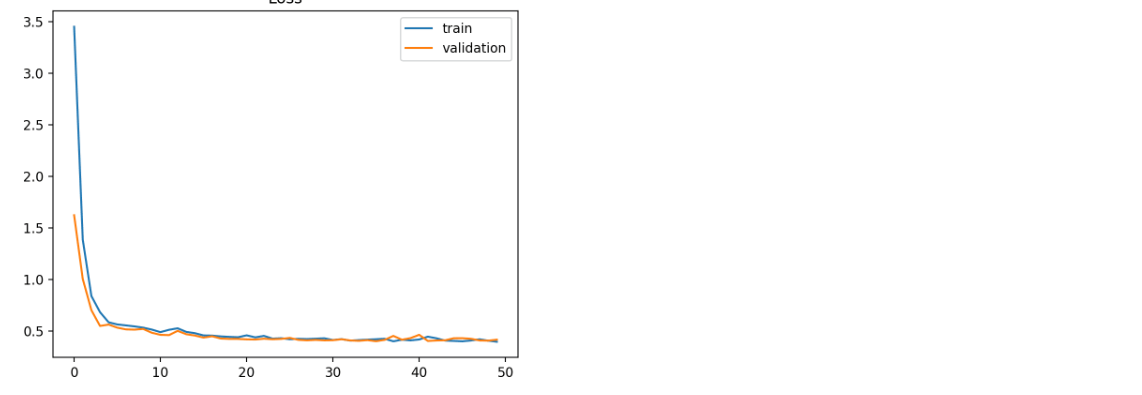

No presente estudo, as curvas de aprendizado são particularmente úteis para comparar o comportamento dos diferentes algoritmos de otimização. Enquanto alguns otimizadores podem apresentar convergência mais rápida (queda acentuada da _loss_ nas primeiras épocas), outros podem demonstrar maior estabilidade ou melhor desempenho na validação. Dessa forma, essas curvas fornecem uma ferramenta essencial para interpretar não apenas o desempenho final, mas também o processo de aprendizado de cada configuração experimental.

#### Visualização das curvas médias

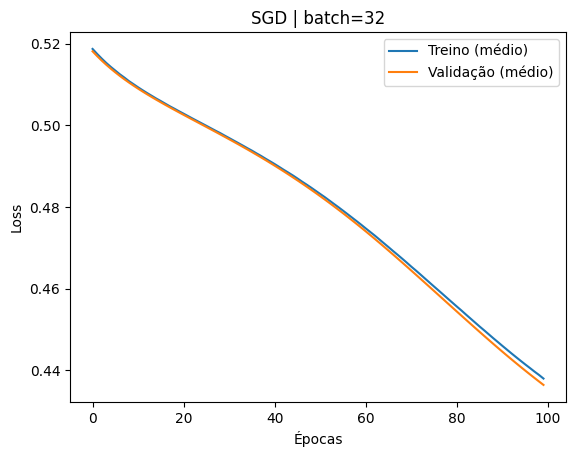

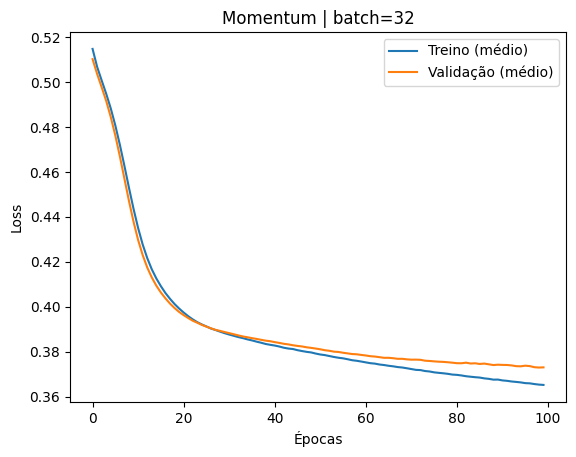

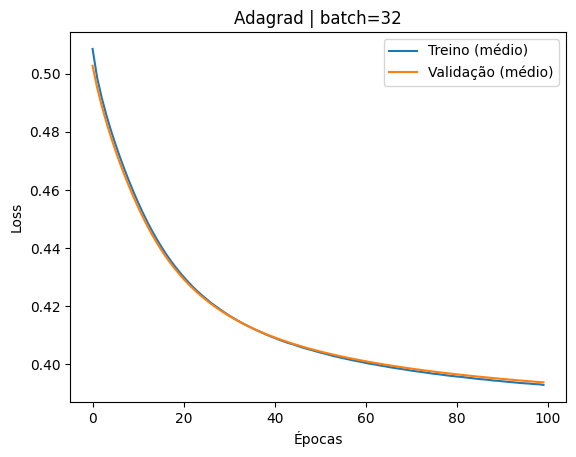

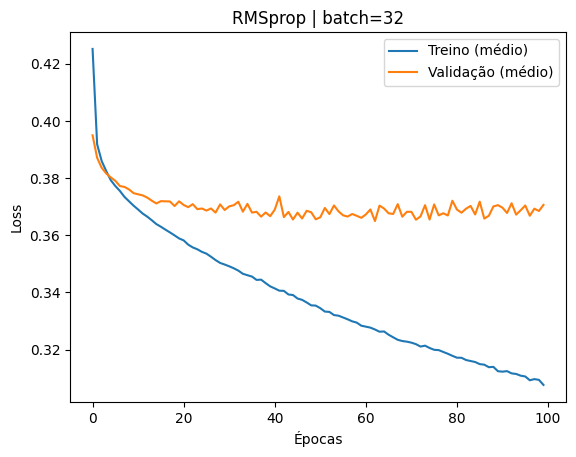

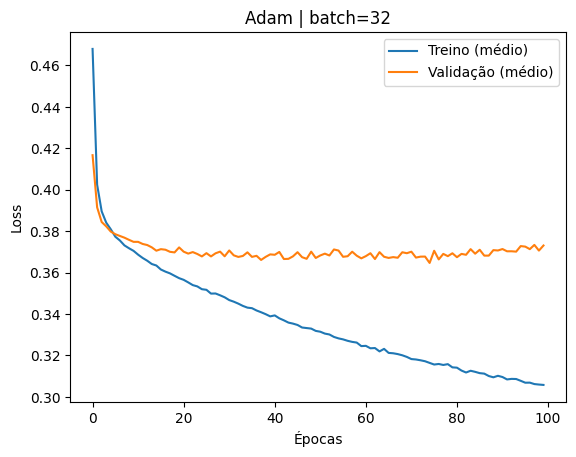

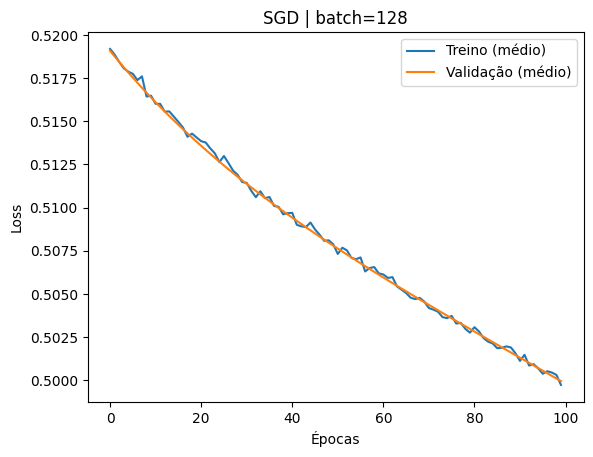

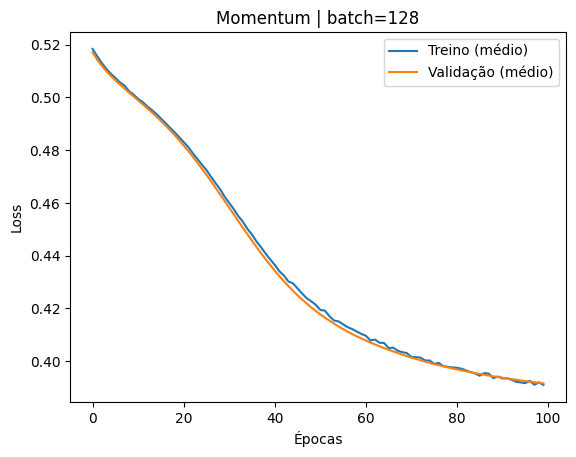

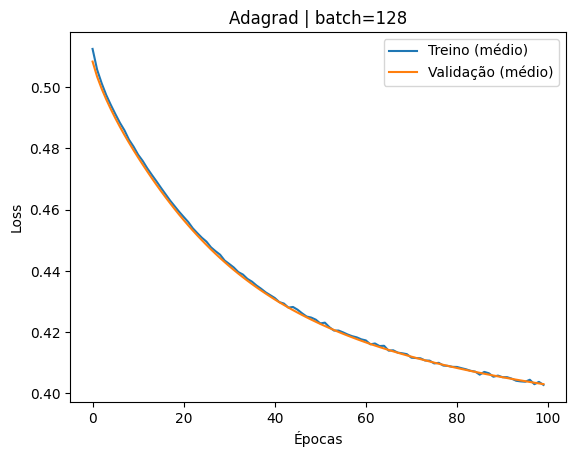

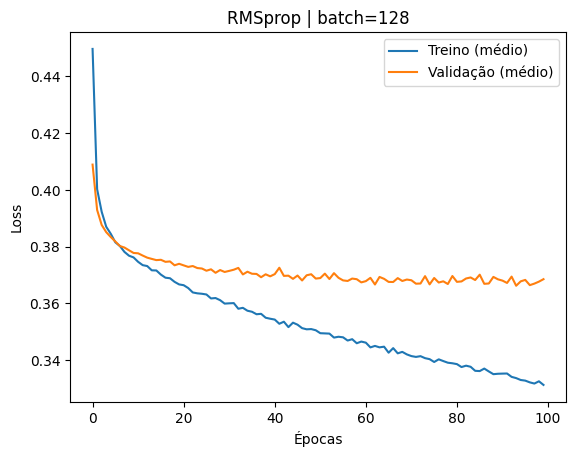

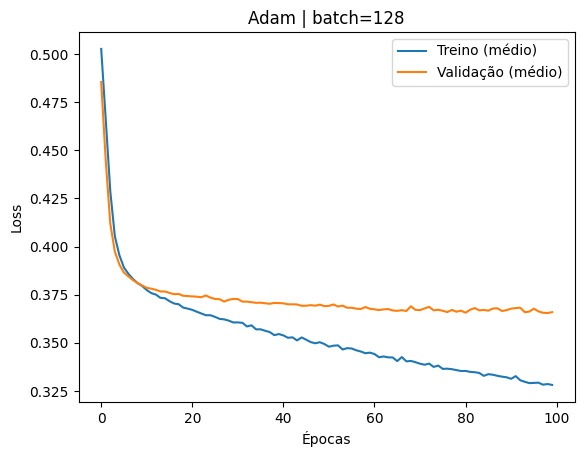

In [8]:
# CURVAS MÉDIAS
for batch in batch_sizes:
    for opt in optimizers:

        all_train = []
        all_val = []

        for seed in SEEDS:
            all_train.append(results_all_seeds[seed][batch][opt]["train_loss"])
            all_val.append(results_all_seeds[seed][batch][opt]["val_loss"])

        mean_train = np.mean(all_train, axis=0)
        mean_val = np.mean(all_val, axis=0)

        plt.figure()
        plt.plot(mean_train, label="Treino (médio)")
        plt.plot(mean_val, label="Validação (médio)")
        plt.title(f"{opt} | batch={batch}")
        plt.xlabel("Épocas")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

### Tabela comparativa das métricas

In [9]:
rows = []

for batch in batch_sizes:
    for opt in optimizers:

        f1s = []
        aucs = []
        accs = []
        val_f1s = []

        for seed in SEEDS:
            r = results_all_seeds[seed][batch][opt]

            f1s.append(r["f1"])
            aucs.append(r["auc"])
            accs.append(r["accuracy"])
            val_f1s.append(r["val_f1"])

        rows.append({
            "Batch": batch,
            "Otimizador": opt,
            "Val_F1_mean": np.mean(val_f1s),
            "Val_F1_std": np.std(val_f1s),
            "Test_Accuracy_mean": np.mean(accs),
            "Test_Accuracy_std": np.std(accs),
            "Test_F1_mean": np.mean(f1s),
            "Test_F1_std": np.std(f1s),
            "Test_AUC_mean": np.mean(aucs),
            "Test_AUC_std": np.std(aucs),
        })

df_results_final = pd.DataFrame(rows)

print(df_results_final.sort_values(by="Test_F1_mean", ascending=False))

   Batch Otimizador  Val_F1_mean  Val_F1_std  Test_Accuracy_mean  \
3     32    RMSprop     0.806823    0.008957            0.758205   
8    128    RMSprop     0.797609    0.006538            0.758974   
4     32       Adam     0.806570    0.010506            0.748718   
9    128       Adam     0.791950    0.004458            0.751026   
1     32   Momentum     0.785966    0.015078            0.748974   
6    128   Momentum     0.758822    0.025747            0.717436   
2     32    Adagrad     0.754659    0.019819            0.716667   
7    128    Adagrad     0.748521    0.018077            0.713846   
0     32        SGD     0.723364    0.040379            0.682308   
5    128        SGD     0.684503    0.126173            0.621282   

   Test_Accuracy_std  Test_F1_mean  Test_F1_std  Test_AUC_mean  Test_AUC_std  
3           0.004714      0.802724     0.004984       0.829749      0.000943  
8           0.005699      0.800782     0.003708       0.831252      0.003726  
4           0.

## Resultados e discussões

Os experimentos avaliaram o desempenho de diferentes algoritmos de otimização no treinamento de uma rede neural MLP para classificação binária utilizando o conjunto *Wine Quality Dataset*. Foram comparados os otimizadores SGD, SGD com Momentum, AdaGrad, RMSProp e Adam, considerando dois tamanhos de mini-batch (32 e 128). As métricas analisadas incluíram Accuracy, F1-score e AUC, além das curvas de aprendizado de treino e validação.

De forma geral, os resultados indicam clara superioridade dos métodos adaptativos e variantes com momentum em relação ao SGD clássico. O melhor desempenho médio em F1-score de teste foi obtido pelo RMSProp com batch size 32  ($F1 = 0.8027 \pm 0.0050$ **), seguido por Adam com batch 32 ($F1 = 0.7897 \pm 0.0036$ ** ) e SGD com Momentum com batch 32 ($F1 = 0.7876 \pm 0.0102$ **). Já o SGD clássico apresentou os piores resultados em praticamente todas as métricas avaliadas, especialmente para batch size 128, onde atingiu apenas $F1 = 0.6763 \pm 0.1381$ **.

A análise da métrica AUC reforça esse comportamento. RMSProp e Adam apresentaram os maiores valores médios de AUC, alcançando aproximadamente $0.83$, enquanto o SGD clássico obteve valores significativamente inferiores, principalmente com batch size 128 ($AUC = 0.6640$). Como a AUC mede a capacidade do modelo separar corretamente exemplos positivos e negativos independentemente do limiar de decisão, esses resultados sugerem que métodos adaptativos aprenderam representações mais discriminativas do problema.

Os desvios padrão também revelam diferenças importantes de estabilidade entre os métodos. RMSProp e Adam apresentaram baixa variabilidade entre execuções, indicando menor sensibilidade às sementes aleatórias e inicializações dos pesos. O RMSProp com batch 32, por exemplo, apresentou desvio padrão de apenas $0.0050$ no F1-score de teste. Em contraste, o SGD clássico apresentou alta variabilidade, especialmente com batch size 128 ($std = 0.1381$), sugerindo comportamento instável e maior dependência das condições iniciais de treinamento.

As curvas de aprendizado reforçam essas observações. O SGD clássico apresentou redução lenta e quase linear da _loss_ ao longo das épocas, especialmente para batch size 128. Mesmo após 100 épocas, a loss permaneceu significativamente acima dos demais métodos, indicando dificuldade de convergência e exploração menos eficiente da superfície de otimização. Esse comportamento é compatível com a ausência de mecanismos adaptativos de ajuste da taxa de aprendizado ou acumulação de gradientes passados.

O uso de momentum produziu melhora substancial em relação ao SGD tradicional. As curvas mostram redução muito mais rápida da loss nas primeiras épocas, principalmente para batch size 32. O momentum acelera atualizações em direções consistentes e reduz oscilações em regiões de alta curvatura da superfície de perda. Entretanto, observou-se queda de desempenho para batch size 128, onde o F1-score médio caiu para aproximadamente $0.7545$. Isso indica que, neste problema, batches menores produziram treinamento mais eficiente e melhor capacidade de generalização.

O AdaGrad apresentou comportamento estável e consistente, porém com convergência progressivamente mais lenta ao longo das épocas. As curvas indicam diminuição contínua da _loss_ sem sinais evidentes de _overfitting_, mas também sem ganhos expressivos após as primeiras dezenas de épocas. Esse comportamento está diretamente relacionado ao mecanismo do AdaGrad, que acumula gradientes históricos e reduz continuamente a taxa de aprendizado dos parâmetros. Embora isso possa estabilizar o treinamento, também tende a limitar melhorias posteriores.

RMSProp e Adam apresentaram os melhores comportamentos de convergência. Ambos reduziram rapidamente a _loss_ nas primeiras épocas e atingiram os maiores valores de F1-score e AUC. Entretanto, as curvas de treino e validação mostram separação gradual após aproximadamente 20 a 30 épocas, especialmente para batch size 32. Nesse cenário, a loss de treino continua diminuindo enquanto a _loss_ de validação permanece aproximadamente constante, indicando início de _overfitting_.

Apesar disso, RMSProp e Adam ainda mantiveram o melhor desempenho preditivo geral. O RMSProp apresentou resultados particularmente consistentes, obtendo os maiores valores médios de F1-score em ambos os batch sizes e baixa variabilidade entre execuções. O Adam apresentou comportamento semelhante, embora com leve tendência a maior _overfitting_ nas curvas de treino.

A comparação entre batch sizes revelou tendências relevantes. Em praticamente todos os otimizadores, batch size 32 produziu desempenho superior ao batch size 128. Esse resultado sugere que batches menores favoreceram a dinâmica de treinamento e a capacidade de generalização no problema estudado. Além disso, batches menores geraram atualizações mais frequentes dos parâmetros, o que provavelmente contribuiu para convergência mais eficiente.

Os testes t pareados reforçam, de forma exploratória, a tendência observada nas métricas e curvas de aprendizado: métodos adaptativos como RMSProp e Adam apresentaram desempenho superior e mais estável em comparação ao SGD clássico e ao AdaGrad, ao comparar os valores de F1-score entre pares de otimizadores. Alguns pares apresentaram evidências estatísticas de diferença, principalmente envolvendo RMSProp e AdaGrad. Para batch size 32, por exemplo, a comparação entre AdaGrad e RMSProp produziu $p = 0.0048$, enquanto AdaGrad versus Adam apresentou $p = 0.0240$. Para batch size 128, diferenças semelhantes também foram observadas entre RMSProp e Momentum ($p = 0.0008$) e entre AdaGrad e Adam ($p = 0.0168$). Entretanto, é importante relembrar que esses resultados devem ser interpretados com cautela, pois foram utilizadas apenas três sementes aleatórias ($n = 3$), o que reduz significativamente o poder estatístico do teste t e dificulta a verificação adequada da hipótese de normalidade das diferenças entre pares.

De maneira geral, métodos adaptativos, especialmente RMSProp e Adam, apresentaram convergência mais rápida, maior estabilidade e melhor desempenho final no problema estudado. Já o SGD clássico demonstrou maior sensibilidade ao tamanho do batch, convergência significativamente mais lenta e maior variabilidade entre execuções.

<span style="font-size:12px;">
** Os resultados são apresentados no formato média ± desvio padrão calculados sobre diferentes sementes aleatórias.
</span>

## Conclusão

Este trabalho investigou o impacto de diferentes algoritmos de otimização no treinamento de redes neurais MLP aplicadas a um problema de classificação binária utilizando o conjunto *Wine Quality Dataset*. Foram analisados os métodos SGD, SGD com Momentum, AdaGrad, RMSProp e Adam, considerando diferentes tamanhos de mini-batch e avaliando métricas como Accuracy, F1-score e AUC.

Os resultados mostraram diferenças claras de comportamento entre os otimizadores. O SGD clássico apresentou convergência mais lenta, maior sensibilidade às sementes aleatórias e pior desempenho geral, especialmente para batch size 128. Em contraste, métodos adaptativos como RMSProp e Adam apresentaram treinamento mais estável, convergência mais rápida e melhores métricas finais de classificação. O RMSProp obteve o melhor desempenho médio em F1-score, além de baixa variabilidade entre execuções, indicando maior robustez do treinamento.

Os experimentos também mostraram que o uso de batches menores favoreceu o desempenho da maioria dos métodos avaliados. De maneira geral, batches menores apresentaram melhor desempenho e maior estabilidade no problema estudado, sugerindo melhor dinâmica de treinamento e maior capacidade de generalização. Além disso, observou-se que o uso de momentum trouxe ganhos relevantes em relação ao SGD tradicional.

A análise das curvas de aprendizado permitiu observar diferenças importantes no comportamento dos métodos ao longo do treinamento. Enquanto SGD e AdaGrad apresentaram redução mais lenta da _loss_, RMSProp e Adam reduziram rapidamente o erro nas primeiras épocas. Entretanto, esses métodos também apresentaram sinais moderados de _overfitting_ após aproximadamente 20 a 30 épocas, evidenciando que métodos capazes de reduzir rapidamente a _loss_ de treinamento nem sempre produzem modelos com melhor capacidade de generalização sobre dados não vistos.

Os testes t pareados foram utilizados como análise complementar exploratória e indicaram evidências estatísticas de diferença entre alguns pares de métodos. Contudo, devido ao número reduzido de sementes aleatórias utilizadas, esses resultados devem ser interpretados com cautela e não como conclusões estatísticas definitivas.

De maneira geral, os resultados obtidos foram coerentes com a literatura da área de aprendizado profundo. Métodos adaptativos demonstraram vantagens importantes em estabilidade e desempenho preditivo, enquanto métodos mais simples, como o SGD clássico, mostraram maior dependência da escolha de hiperparâmetros e do tamanho do batch. O trabalho também evidenciou que a escolha do otimizador exerce impacto significativo não apenas na velocidade de convergência, mas também na qualidade final do modelo treinado.

A escolha do otimizador depende das características do problema, do tamanho do conjunto de dados, da arquitetura utilizada e do comportamento desejado durante o treinamento. Métodos adaptativos como Adam e RMSProp tendem a apresentar convergência rápida e maior estabilidade, enquanto SGD com Momentum pode apresentar melhor generalização em alguns cenários após ajuste cuidadoso de hiperparâmetros.

## Extra ➕✨
### Implementação da descida do gradiente em Python puro

A implementação abaixo demonstra o funcionamento da descida do gradiente com momento em Python puro. O algoritmo mantém uma variável de velocidade que acumula parte do gradiente das iterações anteriores, permitindo atualizações mais estáveis e rápidas.

Observamos a tentativa de previsão da relação:
$$y=2x,$$
sendo 2 o peso $w$.

In [10]:
import random

# Dados simples
X = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Peso inicial
w = random.uniform(-1, 1)

# Hiperparâmetros
lr = 0.01
beta = 0.9
epochs = 100

# Velocidade do momentum
v = 0

for epoch in range(epochs):

    gradiente_total = 0
    loss_total = 0

    for xi, yi in zip(X, y):

        # Forward
        y_pred = w * xi

        # Erro
        erro = y_pred - yi

        # Loss quadrática
        loss = erro ** 2
        loss_total += loss

        # Gradiente
        gradiente = 2 * erro * xi
        gradiente_total += gradiente

    gradiente_medio = gradiente_total / len(X)

    # Momentum
    v = beta * v - lr * gradiente_medio

    # Atualização do peso
    w += v

    if epoch % 10 == 0:
        print("Época:", epoch,
              "Loss:", loss_total / len(X),
              "Peso:", w)

print("\nPeso final:", w)

Época: 0 Loss: 22.72434118948244 Peso: 0.8789011405329664
Época: 10 Loss: 0.5193193890124912 Peso: 1.4521830733563998
Época: 20 Loss: 2.431216444179369 Peso: 2.3126678665354152
Época: 30 Loss: 0.22462808409427396 Peso: 2.235664848337475
Época: 40 Loss: 0.22656266505392192 Peso: 1.9246353551483457
Época: 50 Loss: 0.054397507154600434 Peso: 1.9070657308052599
Época: 60 Loss: 0.017598009928419138 Peso: 2.013005846372225
Época: 70 Loss: 0.010053748092358775 Peso: 2.0342615741653716
Época: 80 Loss: 0.0010198584974626577 Peso: 2.000358124720583
Época: 90 Loss: 0.0015620021823329346 Peso: 1.9881048724710129

Peso final: 2.0016555569888954


Observa-se que o parâmetro inicialmente ultrapassa o valor ótimo (2) devido ao efeito acumulativo do momentum, produzindo oscilações em torno do mínimo da função de perda. Entretanto, ao longo das épocas, essas oscilações diminuem progressivamente até a convergência do modelo para valores próximos da solução ideal, atinigindo um erro mínimo.

## Uso de Inteligência Artifical no trabalho

Modelos de Inteligência Artificial Generativa (ChatGPT e Gemini) foram utilizados como ferramentas de suporte para: (i) fundamentação teórica em tópicos de _Machine Learning_ e _Deep Learning_; (ii) identificação de eventuais erros lógicos nos algoritmos e _pipelines_ dos dados; (iii) refinamento da redação acadêmica; (iv) auxílio na interpretação técnica dos resultados obtidos; e (v) geração de imagens. O uso dessas ferramentas não substituiu a análise crítica da autora, que validou todas as saídas e implementações.

## Referências bibliográficas

[1] UCI Machine Learning Repository. Disponível em: <https://archive.ics.uci.edu/dataset/186/wine+quality>. 

[2] IBM. Rede neural. Disponível em: <https://www.ibm.com/br-pt/think/topics/neural-networks>.

[3] GEEKSFORGEEKS. Hyperparameter tuning with Optuna in PyTorch. Disponível em: <https://www.geeksforgeeks.org/deep-learning/hyperparameter-tuning-with-optuna-in-pytorch/>.

[4] SHAIBU, S. Normalização vs. Padronização: Como saber a diferença. Disponível em: <https://www.datacamp.com/pt/tutorial/normalization-vs-standardization>.

[5] PANDAS. pandas documentation — pandas 1.0.1 documentation. Disponível em: <https://pandas.pydata.org/docs/>.

[6] NUMPY. NumPy Documentation. Disponível em: <https://numpy.org/doc/>.

[7] SCIKIT-LEARN. scikit-learn: Machine Learning in Python. Disponível em: <https://scikit-learn.org/stable/>.

[8] DSA, E. Capítulo 37 - O Efeito do Batch Size no Treinamento de Redes Neurais Artificiais. Disponível em: <https://www.deeplearningbook.com.br/o-efeito-do-batch-size-no-treinamento-de-redes-neurais-artificiais/>.

[9] AUGUSTO, F. Redes Neurais Artificiais. Disponível em: <https://medium.com/oiluna/redes-neurais-artificiais-545d080a0752>. Acesso em: 3 abr. 2026.

[10] EQUIPE DA DATABRICKS. O que é Adagrad? Disponível em: <https://www.databricks.com/br/blog/what-is-adagrad>.

[11] Redes Neurais Artificiais. Disponível em: <https://sites.icmc.usp.br/andre/research/neural/>.

[12] UNIHEIDELBERG. 26.11.2024: SGD with Momentum, ADAM, Backpropagation (Part 1). Disponível em: <https://www.youtube.com/watch?v=nvkeGeh3hUA>.

[13] GEEKSFORGEEKS. Binary Cross Entropy/Log Loss for Binary Classification. Disponível em: <https://www.geeksforgeeks.org/deep-learning/binary-cross-entropy-log-loss-for-binary-classification/>.

[14] BCEWithLogitsLoss — PyTorch 2.7 documentation. Disponível em: <https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html>.

[15] WHY. Why do we sample from log space when optimizing learning rate + regularization params? Disponível em: <https://stats.stackexchange.com/questions/291552/why-do-we-sample-from-log-space-when-optimizing-learning-rate-regularization-p>.‌

[16] THOR, W.-M. Optimization Algorithms. Disponível em: <https://apxml.com/courses/deep-learning-fundamentals-keras/chapter-3-training-deep-neural-networks/optimization-algorithms?>.

[17] Conjuntos de dados: conjuntos de dados com classes desequilibradas. Disponível em: <https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets?hl=pt-br>.

[18] GHOST, S.; DASGUPTA, A. Deep Learning: Fundamentals, Theory and Applications. Springer, 2020. 

[19] GEEKSFORGEEKS. Batch Size in Neural Network. Disponível em: <https://www.geeksforgeeks.org/deep-learning/batch-size-in-neural-network/>.

[20] BLOG, D. C. Understanding F1 Score, Accuracy, ROC-AUC, and PR-AUC Metrics for Models. Disponível em: <https://deepchecks.com/f1-score-accuracy-roc-auc-and-pr-auc-metrics-for-models/>.

[21] SKY ENGINE AI | Synthetic Data Cloud for Vision AI. Disponível em: <https://www.skyengine.ai/blog/using-learning-curves-to-analyse-machine-learning-model-performance>.

[22] torch.utils.data — PyTorch 2.7 documentation. Disponível em: <https://docs.pytorch.org/docs/stable/data.html>.

[23] itertools — Funções que criam iteradores para laços eficientes. Disponível em: <https://docs.python.org/pt-br/3/library/itertools.html>.

[24] GEEKSFORGEEKS. RMSProp Optimizer in Deep Learning. Disponível em: <https://www.geeksforgeeks.org/deep-learning/rmsprop-optimizer-in-deep-learning/>.

[25] JMP STATISTICAL DISCOVERY. Paired t-Test. Disponível em: <https://www.jmp.com/en/statistics-knowledge-portal/inferential-statistics/hypothesis-testing/paired-t-test>.